In [1]:
# !pip install qiskit
# pip install qiskit-ibm-runtime
# pip install qiskit[visualization]
# pip install qiskit-aer

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Importing standard Qiskit libraries

from qiskit import QuantumCircuit
from qiskit import QuantumRegister, ClassicalRegister

from qiskit_aer import AerSimulator
from qiskit import transpile

from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit.visualization import array_to_latex

from qiskit.result import Counts

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit.transpiler import generate_preset_pass_manager

In [ ]:
MiToken = "Pegue aquí su API Token de IBM Quantum"
MiInstance = "crn:v1:.... complete su instancia de IBM Quantum"
Channel = "ibm_cloud"

In [6]:
service = QiskitRuntimeService(channel=Channel,
            token=MiToken, # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
            instance=MiInstance)            

In [7]:
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

In [8]:
IBMQProcessor = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

In [9]:
print("El computador cuántico menos ocupado es el:", IBMQProcessor.name)
print("Y posee un número de ", IBMQProcessor.num_qubits, "qubits reales.")

El computador cuántico menos ocupado es el: ibm_fez
Y posee un número de  156 qubits reales.


In [10]:
# Create a new circuit with two qubits
primercircuito = QuantumCircuit(2)

# Add a Sigma X gate to qubit 0
primercircuito.x(0)

# Add a Hadamard gate to qubit 1
primercircuito.h(1)

In [11]:
state = Statevector(primercircuito)

# print(state)
display(array_to_latex(state, prefix="\\ket{State_{out}} = "))

<IPython.core.display.Latex object>

In [12]:
state.draw('latex')  # Visual view of amplitudes

<IPython.core.display.Latex object>

In [13]:
primercircuito.measure_all()

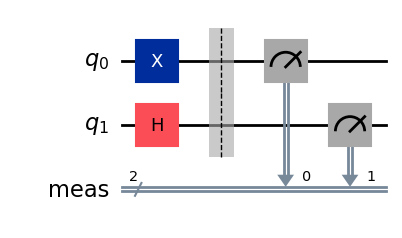

In [14]:
# Return a drawing of the circuit using MatPlotLib ("mpl"). This is the
# last line of the cell, so the drawing appears in the cell output.
# Remove the "mpl" argument to get a text drawing.
primercircuito.draw("mpl")

In [15]:
# MiSimuladorCuantico = AerSimulator()
# job = MiSimuladorCuantico.run(transpile(primercircuito, MiSimuladorCuantico), shots=2048)
# conteo = job.result().get_counts(primercircuito)

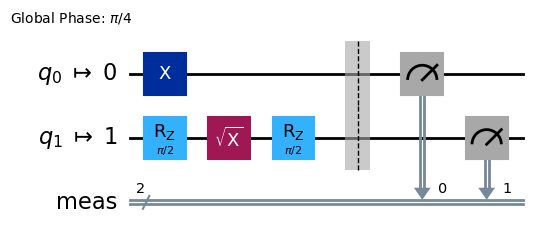

In [16]:
pm = generate_preset_pass_manager(optimization_level=1, backend=IBMQProcessor)
isa_circuit = pm.run(primercircuito)

isa_circuit.draw('mpl')
# plt.show()

In [17]:
# Define the Sampler to run the circuit on a QPU
sampler2run = Sampler(mode=IBMQProcessor)

# Define the number of shots for the execution.
shotno=2048

# Run the circuit on a real quantum computer. This may take a while.
job = sampler2run.run([isa_circuit], shots= shotno)

# ID del Job para rastrear la ejecución del circuito en tiempo real.
print(f">>> ID de la ejecución en el QPU escogido: {job.job_id()}")

# Consulta del estado de la ejecución del circuito cuántico
print(f">>> Estado de la ejecución en el QPU escogido: {job.status()}")

print('Ejecutando el circuito (job) en el QPU de IBM ...\n')

>>> ID de la ejecución en el QPU escogido: davf5sal7guc73cepki0
>>> Estado de la ejecución en el QPU escogido: QUEUED
Ejecutando el circuito (job) en el QPU de IBM ...



In [18]:
# job_id = "ID del Job que se muestra en la salida de la celda anterior"
# job = service.job(job_id)

In [19]:
# Consulta del estado de la ejecución del circuito cuántico
print(f">>> Estado de la ejecución en el QPU escogido: {job.status()}")

>>> Estado de la ejecución en el QPU escogido: QUEUED


In [20]:
result = job.result()
# Get results for the first (and only) PUB

pub_result = result[0]
# Get count measurement results

In [21]:
conteo = pub_result.data.meas.get_counts()
print('Conteo de resultados por cada medida: ', conteo, '\n')

Conteo de resultados por cada medida:  {'11': 1016, '01': 981, '10': 25, '00': 26} 



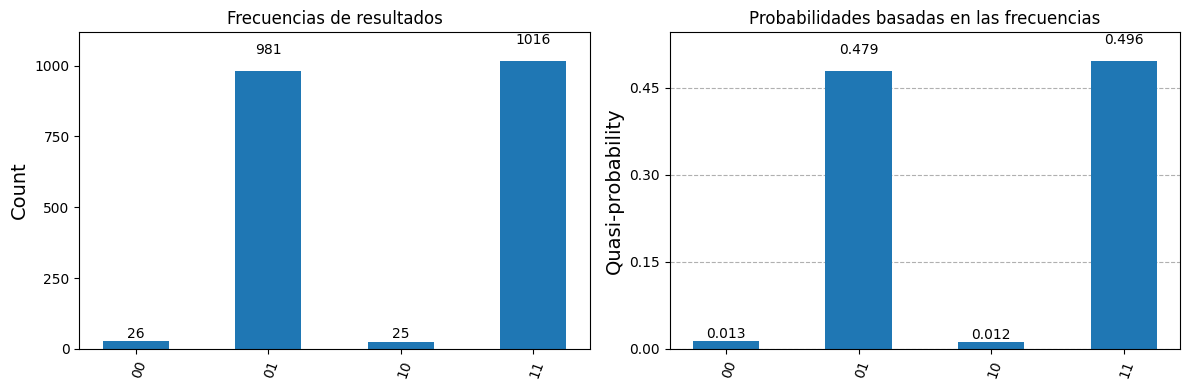

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot histogram in each subplot
plot_histogram(conteo, ax=axs[0])
plot_distribution(conteo, ax=axs[1])

axs[0].set_title("Frecuencias de resultados")
axs[1].set_title("Probabilidades basadas en las frecuencias")

plt.tight_layout()
plt.show()

In [23]:
from qiskit import __version__ as qiskit_version
from qiskit_aer import __version__ as aer_version
from platform import python_version

print('Qiskit Version:', qiskit_version)
print('Qiskit_Aer Version:', aer_version)
print('Python Version:', python_version())
print('UdeA-Medellin (2026) ©')

Qiskit Version: 2.0.0
Qiskit_Aer Version: 0.17.0
Python Version: 3.13.2
UdeA-Medellin (2026) ©
